In [ ]:
import os
import glob
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
from shapely.geometry import box

# user inputs
input_folder = ''
shapefile_path = ''
output_folder = ''

# read shapefile
shapefile = gpd.read_file(shapefile_path)

# list all tiff files
tiff_files = glob.glob(os.path.join(input_folder, '*.tif'))
os.makedirs(output_folder, exist_ok=True)

# process each tiff
for tif_path in tiff_files:
    try:
        with rasterio.open(tif_path) as src:

            if src.crs is None:
                print(f"Skipping file with no CRS: {tif_path}")
                continue

            # reproject shapefile to match raster
            shp_proj = shapefile.to_crs(src.crs)

            # check overlap
            raster_bounds = box(*src.bounds)
            shapes = [g for g in shp_proj.geometry if g is not None and g.intersects(raster_bounds)]

            if not shapes:
                print(f"No overlap with raster: {tif_path}")
                continue

            # mask raster, keep only data inside shapefile
            out_image, out_transform = rasterio.mask.mask(
                src,
                shapes,
                crop=False,
                invert=False,
                filled=True
            )

            # convert to float for NaN support
            out_image = out_image.astype("float32")

            # replace masked pixels with NaN
            if src.nodata is not None:
                out_image[out_image == src.nodata] = np.nan
            else:
                # if raster had no nodata, masked areas may be 0
                out_image[out_image == 0] = np.nan

            # update metadata
            out_meta = src.meta.copy()
            out_meta.update({
                "dtype": "float32",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })
            out_meta.pop("nodata", None)

            # save output
            filename = os.path.basename(tif_path)
            output_path = os.path.join(
                output_folder,
                filename.replace('.tif', '_masked.tif')
            )

            with rasterio.open(output_path, "w", **out_meta) as dest:
                dest.write(out_image)

            print(f"Processed: {output_path}")

    except Exception as e:
        print(f"Error processing {tif_path}: {e}")


In [2]:
import os
import glob
import shutil
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np

# =========================
# CONFIG
# =========================
PLANET_ROOT   = "/pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove"
LANDMASK_ROOT = "/pscratch/sd/k/kevinval/coraltest/ct_classifier/land_mask"
OUT_ROOT      = "/pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove_landmasked"

INVERT = True                 # True = remove land inside polygons
COPY_IF_NO_LANDMASK = True

# Site-name aliases: map planet site folder -> landmask folder key to search for
# (all comparisons are case-insensitive substring matches)
SITE_ALIASES = {
    "santacruz_mexico": "santacruz",                 # landmask folder: santacruz_landmask
    "northpoint_lizard": "lizard_island_australia",  # landmask folder: lizard_island_australia_landmask
}

# =========================
# helpers
# =========================
def list_landmask_dirs():
    dirs = [d for d in glob.glob(os.path.join(LANDMASK_ROOT, "*")) if os.path.isdir(d)]
    dirs = [d for d in dirs if "landmask" in os.path.basename(d).lower()]
    return dirs

def find_landmask_shp(site_name: str) -> str | None:
    """
    Find a shapefile for a site's landmask.
    Tries:
      1) exact folder match: <site>_landmask/*.shp
      2) alias key match (if present)
      3) substring match on site_name
      4) substring match on base site token (before first underscore)
    """
    # 1) exact match
    exact = glob.glob(os.path.join(LANDMASK_ROOT, f"{site_name}_landmask", "*.shp"))
    if exact:
        return exact[0]

    landmask_dirs = list_landmask_dirs()
    if not landmask_dirs:
        return None

    def first_shp(d):
        shps = glob.glob(os.path.join(d, "*.shp"))
        return shps[0] if shps else None

    site_lower = site_name.lower()

    # 2) alias match
    alias_key = SITE_ALIASES.get(site_name, None)
    if alias_key is not None:
        key = alias_key.lower()
        for d in landmask_dirs:
            if key in os.path.basename(d).lower():
                shp = first_shp(d)
                if shp:
                    return shp

    # 3) substring match using full site name
    for d in landmask_dirs:
        if site_lower in os.path.basename(d).lower():
            shp = first_shp(d)
            if shp:
                return shp

    # 4) fallback: use base token (before first underscore)
    base = site_lower.split("_")[0]
    for d in landmask_dirs:
        if base in os.path.basename(d).lower():
            shp = first_shp(d)
            if shp:
                return shp

    return None

def mask_one_tif(tif_path: str, shp: gpd.GeoDataFrame, out_path: str, invert: bool):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    with rasterio.open(tif_path) as src:
        if src.crs is None:
            raise ValueError("Raster has no CRS; cannot align shapefile.")

        shp_proj = shp.to_crs(src.crs)
        geoms = [g for g in shp_proj.geometry if g is not None and not g.is_empty]
        if not geoms:
            raise ValueError("Shapefile has no valid geometries.")

        out_img, out_transform = rasterio.mask.mask(
            src,
            geoms,
            crop=False,
            invert=invert,
            filled=False
        )

        out_img = out_img.astype(np.float32).filled(np.nan)

        out_meta = src.meta.copy()
        out_meta.update({
            "dtype": "float32",
            "height": out_img.shape[1],
            "width": out_img.shape[2],
            "transform": out_transform,
        })
        out_meta.pop("nodata", None)

        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(out_img)

def copy_one_tif(src_path: str, out_path: str):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    shutil.copy2(src_path, out_path)

# =========================
# main traversal
# =========================
site_dirs = sorted([d for d in glob.glob(os.path.join(PLANET_ROOT, "*")) if os.path.isdir(d)])
print(f"Found {len(site_dirs)} site folders under {PLANET_ROOT}")

for site_dir in site_dirs:
    site_name = os.path.basename(site_dir)

    tif_paths = glob.glob(os.path.join(site_dir, "*", "tiled_360m", "*", "loc*.tif"))
    print(f"\n[{site_name}] tiles={len(tif_paths)}")

    shp_path = find_landmask_shp(site_name)
    print(f"  landmask shp: {shp_path}")

    if shp_path is None:
        print(f"  [NO LANDMASK] copying tiles unchanged -> {OUT_ROOT}")
        if not COPY_IF_NO_LANDMASK:
            continue
        for tif_path in tif_paths:
            rel = os.path.relpath(tif_path, PLANET_ROOT)
            out_path = os.path.join(OUT_ROOT, rel)
            try:
                copy_one_tif(tif_path, out_path)
            except Exception as e:
                print(f"  [ERR COPY] {tif_path} -> {e}")
        continue

    try:
        shp = gpd.read_file(shp_path)
    except Exception as e:
        print(f"  [ERR] Failed to read shapefile: {shp_path} ({e})")
        print(f"  [FALLBACK] copying tiles unchanged instead")
        for tif_path in tif_paths:
            rel = os.path.relpath(tif_path, PLANET_ROOT)
            out_path = os.path.join(OUT_ROOT, rel)
            try:
                copy_one_tif(tif_path, out_path)
            except Exception as ee:
                print(f"  [ERR COPY] {tif_path} -> {ee}")
        continue

    print(f"  [LANDMASK] using {os.path.basename(os.path.dirname(shp_path))} invert={INVERT}")

    for tif_path in tif_paths:
        rel = os.path.relpath(tif_path, PLANET_ROOT)
        out_path = os.path.join(OUT_ROOT, rel)

        try:
            mask_one_tif(tif_path, shp, out_path, invert=INVERT)
        except Exception as e:
            print(f"  [ERR MASK] {tif_path} -> {e}")

Found 12 site folders under /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove

[chachacual_mexico] tiles=130
  landmask shp: /pscratch/sd/k/kevinval/coraltest/ct_classifier/land_mask/chachacual_mexico_landmask/chachacual_landmask.shp
  [LANDMASK] using chachacual_mexico_landmask invert=True

[cheeca_flkeys] tiles=80
  landmask shp: None
  [NO LANDMASK] copying tiles unchanged -> /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove_landmasked

[easterndry_flkeys] tiles=52
  landmask shp: None
  [NO LANDMASK] copying tiles unchanged -> /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove_landmasked

[jicaral_mexico] tiles=104
  landmask shp: /pscratch/sd/k/kevinval/coraltest/ct_classifier/land_mask/jicaral_mexico_landmask/jicaral_landmask.shp
  [LANDMASK] using jicaral_mexico_landmask invert=True

[lbcaye_bbr] tiles=12
  landmask shp: None
  [NO LANDMASK] copying tiles unchanged -> /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove_lan

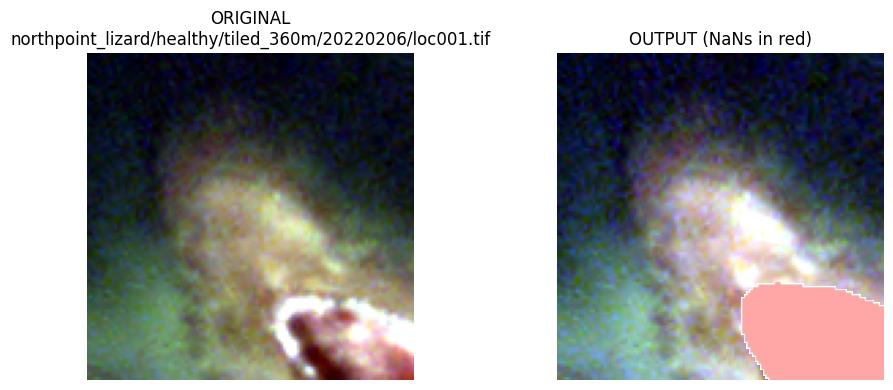

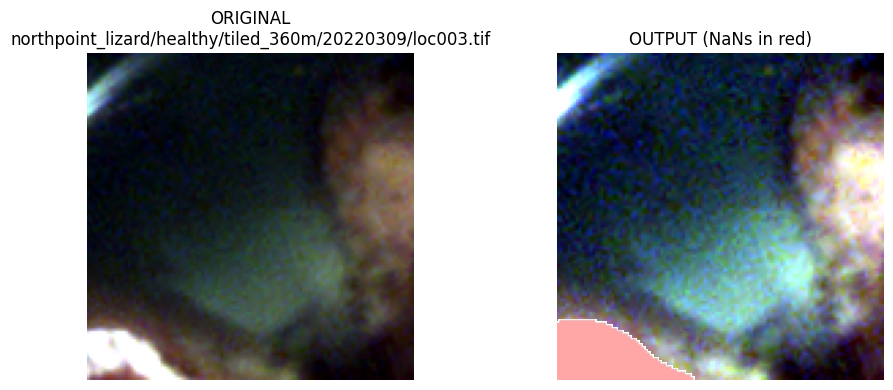

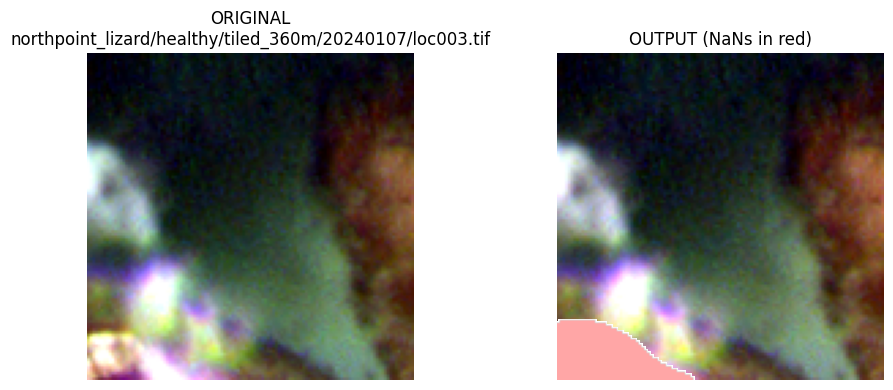

In [4]:
import os, glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt

PLANET_ROOT = "/pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove"
OUT_ROOT    = "/pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove_landmasked"

# Pick a site + class to sample from (edit these)
SITE = "northpoint_lizard"
CLS  = "healthy"   # "healthy" or "bleached"

# band indices (1-indexed for rasterio.read)
# Change if colors look weird.
RGB_BANDS = (3, 2, 1)

# how many random tiles to show
N = 3

def read_rgb(path, rgb_bands=(3,2,1)):
    with rasterio.open(path) as src:
        arr = src.read(list(rgb_bands)).astype(np.float32)  # [3,H,W]
    arr = np.transpose(arr, (1,2,0))  # [H,W,3]

    # robust normalization for display
    lo = np.nanpercentile(arr, 2, axis=(0,1))
    hi = np.nanpercentile(arr, 98, axis=(0,1))
    arr = (arr - lo) / (hi - lo + 1e-6)
    arr = np.clip(arr, 0, 1)
    return arr

def nan_mask(path):
    with rasterio.open(path) as src:
        x = src.read(1).astype(np.float32)
    return np.isnan(x)

# gather some tiles
pattern = os.path.join(PLANET_ROOT, SITE, CLS, "tiled_360m", "*", "loc*.tif")
tiles = sorted(glob.glob(pattern))
assert len(tiles) > 0, f"No tiles found for: {pattern}"

# choose a few evenly spaced (deterministic) instead of random
idxs = np.linspace(0, len(tiles)-1, num=min(N, len(tiles)), dtype=int)
chosen = [tiles[i] for i in idxs]

for p in chosen:
    rel = os.path.relpath(p, PLANET_ROOT)
    out_p = os.path.join(OUT_ROOT, rel)

    if not os.path.exists(out_p):
        print(f"[WARN] output missing: {out_p}")
        continue

    rgb_in  = read_rgb(p, RGB_BANDS)
    rgb_out = read_rgb(out_p, RGB_BANDS)
    mask_out = nan_mask(out_p)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(rgb_in)
    axes[0].set_title(f"ORIGINAL\n{rel}")
    axes[0].axis("off")

    axes[1].imshow(rgb_out)
    # overlay NaN mask in red
    overlay = np.zeros((*mask_out.shape, 4), dtype=np.float32)
    overlay[mask_out, :] = (1, 0, 0, 0.35)  # red w/ alpha
    axes[1].imshow(overlay)
    axes[1].set_title("OUTPUT (NaNs in red)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [3]:
import re
from pathlib import Path

ROOT = Path("/pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove")

# What to remove (by loc id)
TARGETS = {
    "cheeca": {"loc002"},
    "northpoint_lizard": {"loc004"},
}

DO_DELETE = True  # <- set True after dry-run looks correct

def pick_site_dir(root: Path, key: str) -> Path | None:
    """
    Pick the first site dir whose name contains `key` (case-insensitive).
    """
    key = key.lower()
    candidates = [p for p in root.iterdir() if p.is_dir() and key in p.name.lower()]
    return candidates[0] if candidates else None

def matches_loc(fname: str, loc_set: set[str]) -> bool:
    """
    Match loc002*.tif, loc004*.tif, etc.
    Accepts loc002.tif, loc002_masked.tif, loc002_anything.tif ...
    """
    f = fname.lower()
    return any(f.startswith(loc) and f.endswith(".tif") for loc in loc_set)

# Resolve real site folder names
resolved = {}
for key in TARGETS:
    site_dir = pick_site_dir(ROOT, key)
    resolved[key] = site_dir

print("ROOT:", ROOT)
print("\nResolved site dirs:")
for k, v in resolved.items():
    print(f"  {k:>18s} -> {v}")

to_delete = []

for key, locs in TARGETS.items():
    site_dir = resolved[key]
    if site_dir is None:
        print(f"\n[WARN] Could not find a site folder containing '{key}'.")
        continue

    for tif in site_dir.rglob("loc*.tif"):
        if matches_loc(tif.name, locs):
            to_delete.append(tif)

print("\nFiles to delete:", len(to_delete))
for p in to_delete[:60]:
    print("  ", p)

if DO_DELETE:
    for p in to_delete:
        p.unlink()
    print("\nDeleted:", len(to_delete))
else:
    print("\nDRY RUN ONLY. If this list looks right, set DO_DELETE=True and rerun.")

ROOT: /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove

Resolved site dirs:
              cheeca -> /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove/cheeca_flkeys
   northpoint_lizard -> /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove/northpoint_lizard

Files to delete: 48
   /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove/cheeca_flkeys/healthy/tiled_360m/20230604/loc002.tif
   /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove/cheeca_flkeys/healthy/tiled_360m/20210811/loc002.tif
   /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove/cheeca_flkeys/healthy/tiled_360m/20230605/loc002.tif
   /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove/cheeca_flkeys/healthy/tiled_360m/20210905/loc002.tif
   /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove/cheeca_flkeys/healthy/tiled_360m/20210831/loc002.tif
   /pscratch/sd/k/kevinval/coraltest/ct_classifier/planet_superdove/chee